In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# make columns viewed max =50
pd.set_option('display.max_columns', 50)

In [214]:
df_raw = pd.read_csv("celonis_data.csv")


In [215]:
columns_used = ['Id', 'NextReleaseDate', 'OldHorizonIssueDate', 'HorizonIssueDate',
       'ReleaseDate', 'DateTimeCreated', 'InternalPartNumber',
       'KeytoTRLP', 'ABCCode','Release', 'ReleaseQuantityNet', 'ReleaseQuantityCum',
       'OldRelease', 'OldQuantity', 'ShippedQ',]
df = df_raw[columns_used]

In [ ]:
df.loc[(df["DateTimeCreated"] != df["HorizonIssueDate"])]

,DateTimeCreated,HorizonIssueDate
11702,2023-08-21,2023-08-14
11703,2023-08-21,2023-08-14
11704,2023-08-21,2023-08-14
11705,2023-08-21,2023-08-14
11706,2023-08-21,2023-08-14
...,...,...
56406,2022-03-02,2022-02-28
56407,2022-03-02,2022-02-28
56408,2022-03-02,2022-02-28
56409,2022-03-02,2022-02-28


In [221]:
df.loc[df["InternalPartNumber"] == "92724A"].groupby("ReleaseDate").count().sort_values("Id", ascending=False).sort_values("ReleaseDate").tail(20)

,Id,NextReleaseDate,OldHorizonIssueDate,HorizonIssueDate,DateTimeCreated,InternalPartNumber,KeytoTRLP,ABCCode,Release,ReleaseQuantityNet,ReleaseQuantityCum,OldRelease,OldQuantity,ShippedQ
ReleaseDate,,,,,,,,,,,,,,
2025-08-18,8,8,7,8,8,8,8,0,8,8,8,7,7,0
2025-08-25,8,8,7,8,8,8,8,0,8,8,8,7,7,8
2025-09-01,8,8,7,8,8,8,8,0,8,8,8,7,7,0
2025-09-08,9,9,8,9,9,9,9,0,9,9,9,8,8,9
2025-09-15,8,8,8,8,8,8,8,0,8,8,8,8,8,8
2025-09-22,9,9,9,9,9,9,9,0,9,9,9,9,9,9
2025-09-29,8,8,8,8,8,8,8,0,8,8,8,8,8,8
2025-10-06,8,8,8,8,8,8,8,0,8,8,8,8,8,0
2025-10-13,8,8,7,8,8,8,8,0,8,8,8,7,7,8


1383     2025-10-27
1072     2025-11-03
1301     2025-11-10
1141     2025-11-17
18944    2025-11-24
18994    2025-12-01
2316     2025-12-08
2401     2025-12-15
2291     2025-12-22
2320     2025-12-29
Name: ReleaseDate, dtype: object
Release Date: 2025-10-27
Release Date: 2025-11-03
Release Date: 2025-11-10
Release Date: 2025-11-17
Release Date: 2025-11-24
Release Date: 2025-12-01
Release Date: 2025-12-08
Release Date: 2025-12-15
Release Date: 2025-12-22
Release Date: 2025-12-29


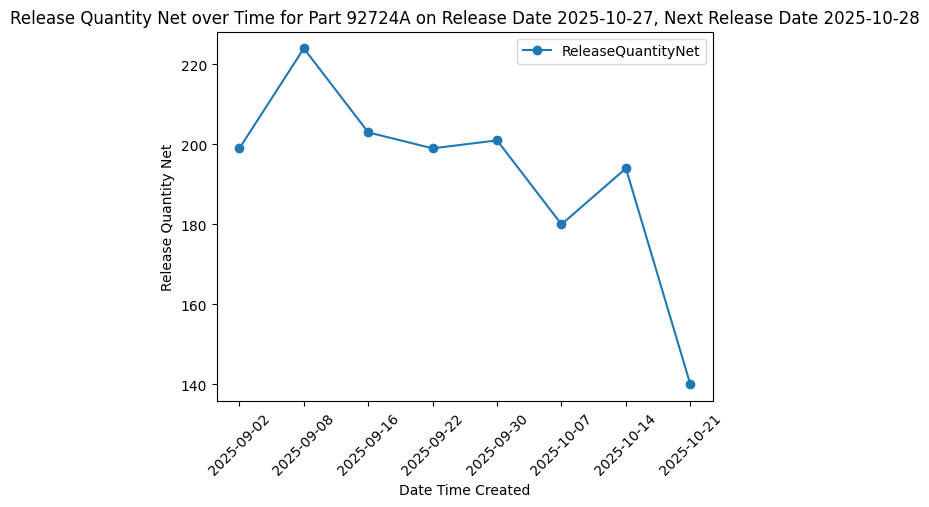

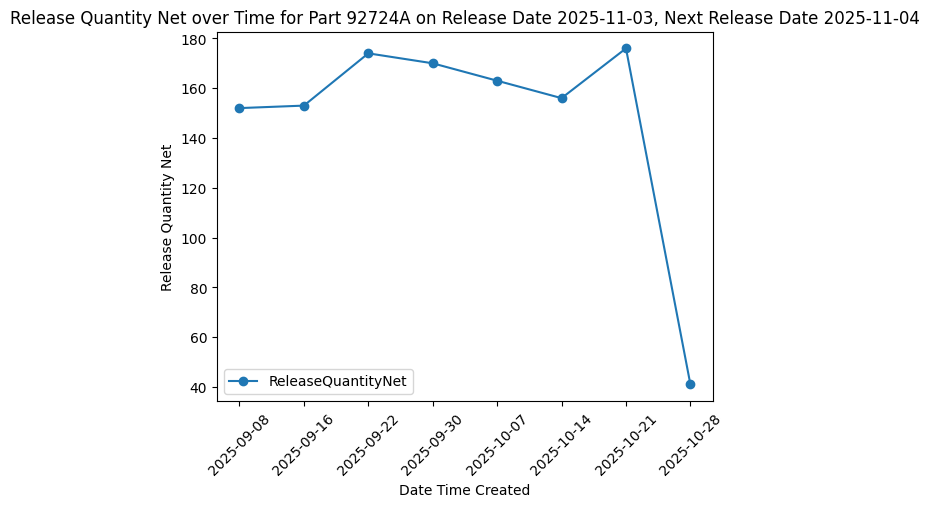

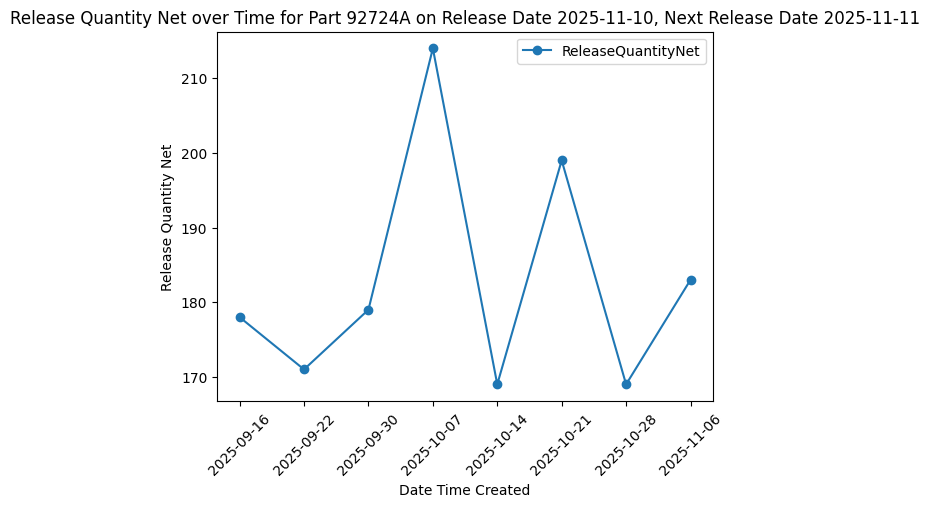

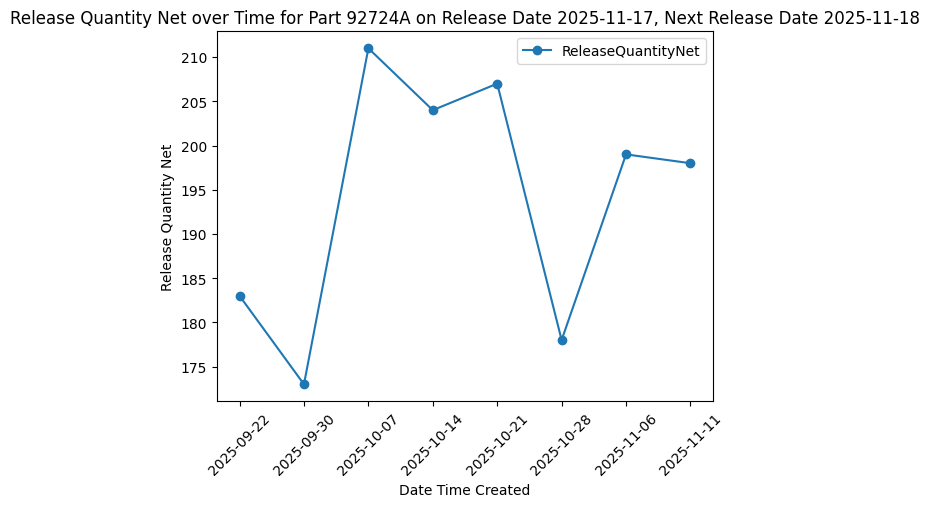

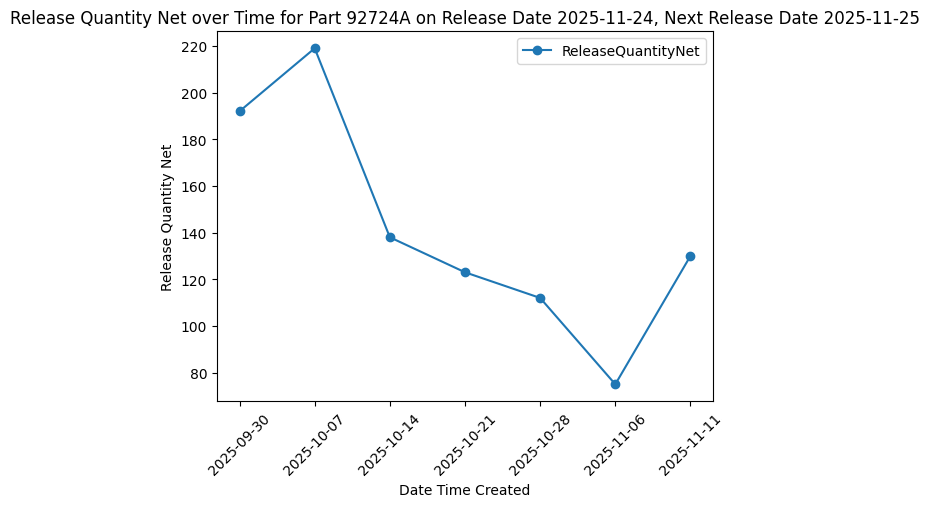

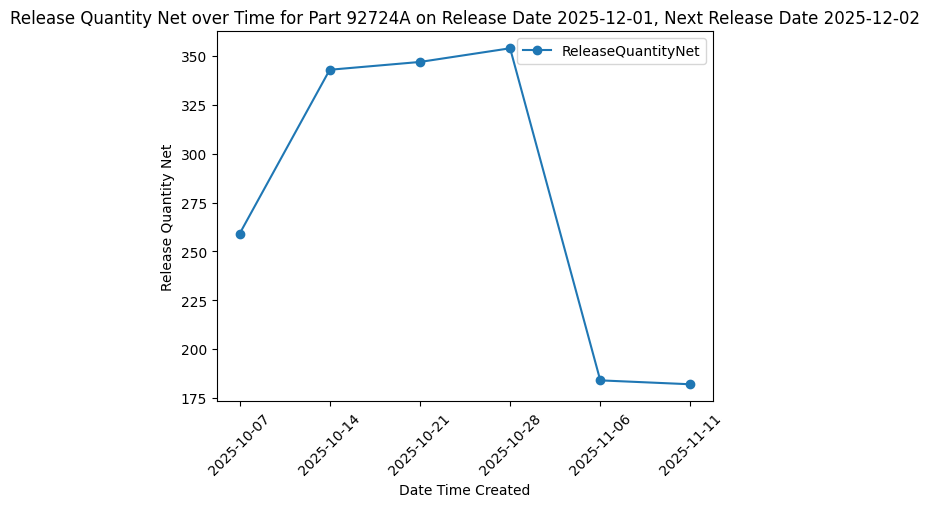

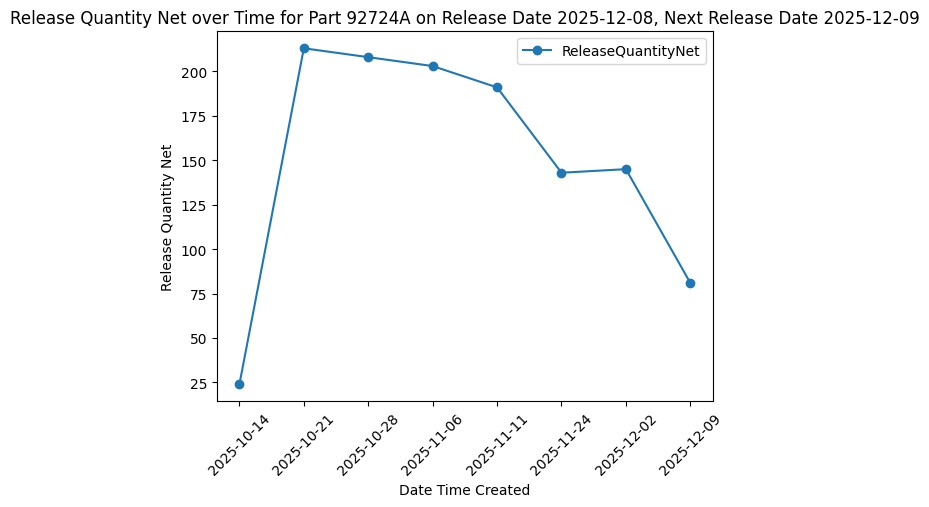

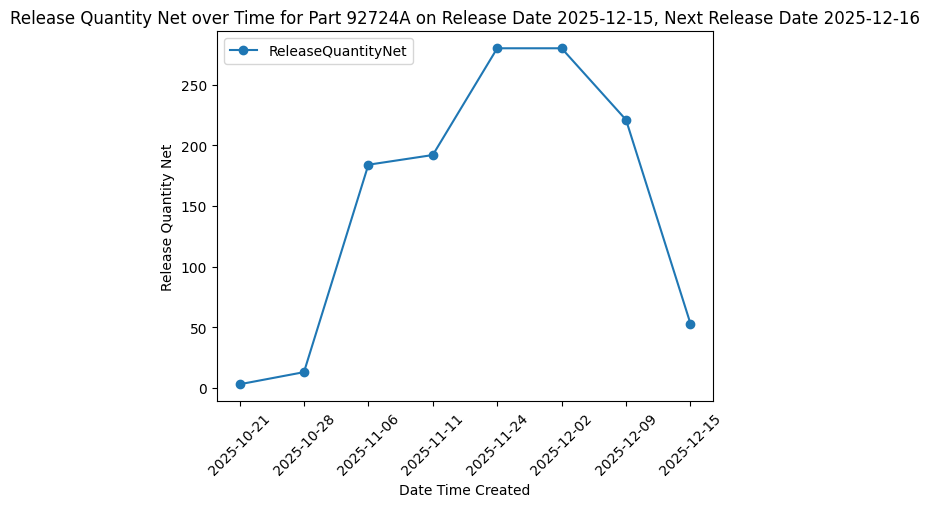

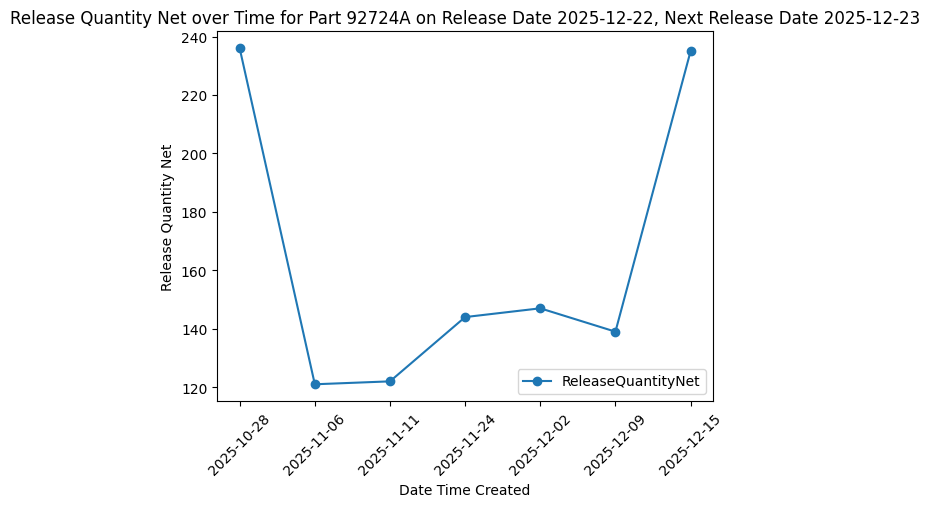

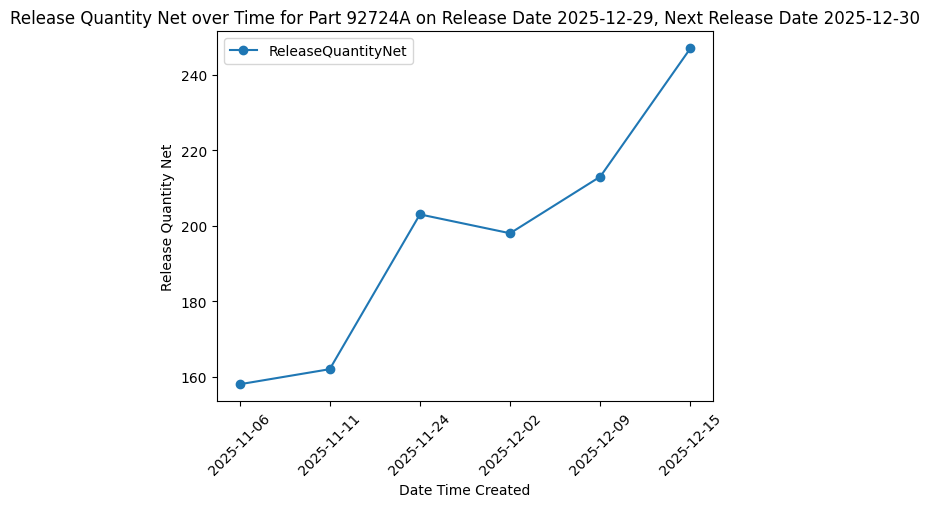

In [236]:
# check one part and make sense of dates

df_part = df[df["InternalPartNumber"] == "92724A"]
# select 5 random dates
dates = df_part["ReleaseDate"].drop_duplicates().sort_values().tail(10)
print(dates)
for date in dates:
    df_part_release = df_part.loc[df_part["ReleaseDate"] == date]
    print(f"Release Date: {date}")
    # Try to replicate the figure
    df_part_release.sort_values("DateTimeCreated").plot(
        x="DateTimeCreated", y="ReleaseQuantityNet", kind="line", marker = "o")
    NextReleaseDate = df_part_release["NextReleaseDate"].iloc[0]
    plt.title(f"Release Quantity Net over Time for Part 92724A on Release Date {date}, Next Release Date {NextReleaseDate}")
    plt.xlabel("Date Time Created")
    # rotate x ticks
    plt.xticks(rotation = 45)
    plt.ylabel("Release Quantity Net")

In [206]:
df_part

,Id,NextReleaseDate,OldHorizonIssueDate,HorizonIssueDate,ReleaseDate,DateTimeCreated,InternalPartNumber,KeytoTRLP,ABCCode,Release,ReleaseQuantityNet,ReleaseQuantityCum,OldRelease,OldQuantity,ShippedQ
77,3127_2024-10-21 00:00:00_2024-09-09 00:00:00,2024-10-22,2024-09-02,2024-09-09,2024-10-21,2024-09-09,92724A,3127,NaN,240909-41670-0002,144,21296,240902-41325-0001,30.0,NaN
110,3127_2024-09-23 00:00:00_2024-09-09 00:00:00,2024-09-24,2024-09-02,2024-09-09,2024-09-23,2024-09-09,92724A,3127,NaN,240909-41670-0002,146,20680,240902-41325-0001,85.0,NaN
114,3127_2024-10-28 00:00:00_2024-09-09 00:00:00,2024-10-29,2024-09-02,2024-09-09,2024-10-28,2024-09-09,92724A,3127,NaN,240909-41670-0002,199,21495,240902-41325-0001,40.0,NaN
194,3127_2024-10-07 00:00:00_2024-09-09 00:00:00,2024-10-08,2024-09-02,2024-09-09,2024-10-07,2024-09-09,92724A,3127,NaN,240909-41670-0002,132,21023,240902-41325-0001,23.0,192.0
220,3127_2024-11-04 00:00:00_2024-09-09 00:00:00,2024-11-05,NaN,2024-09-09,2024-11-04,2024-09-09,92724A,3127,NaN,240909-41670-0002,443,21938,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55691,3127_2025-12-22 00:00:00_2025-11-11 00:00:00,2025-12-23,2025-11-10,2025-11-11,2025-12-22,2025-11-11,92724A,3127,NaN,251111-53883-0002,122,31742,251110-53714-0001,21.0,NaN
55714,3127_2025-12-15 00:00:00_2025-11-11 00:00:00,2025-12-16,2025-11-10,2025-11-11,2025-12-15,2025-11-11,92724A,3127,NaN,251111-53883-0002,192,31620,251110-53714-0001,32.0,72.0
55750,3127_2025-11-24 00:00:00_2025-11-11 00:00:00,2025-11-25,2025-11-10,2025-11-11,2025-11-24,2025-11-11,92724A,3127,NaN,251111-53883-0002,130,31055,251110-53714-0001,130.0,NaN
55756,3127_2025-12-29 00:00:00_2025-11-11 00:00:00,2025-12-30,2025-11-10,2025-11-11,2025-12-29,2025-11-11,92724A,3127,NaN,251111-53883-0002,162,31904,251110-53714-0001,42.0,NaN


In [212]:
df_part["ReleaseDate"] = pd.to_datetime(df_part["ReleaseDate"])

/var/folders/fj/lf41s2h17nbgr6r8vnlcyb4c0000gr/T/ipykernel_98625/1766505683.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_part["ReleaseDate"] = pd.to_datetime(df_part["ReleaseDate"])


Release Date: 2025-11-24


Text(0, 0.5, 'Release Quantity Net')

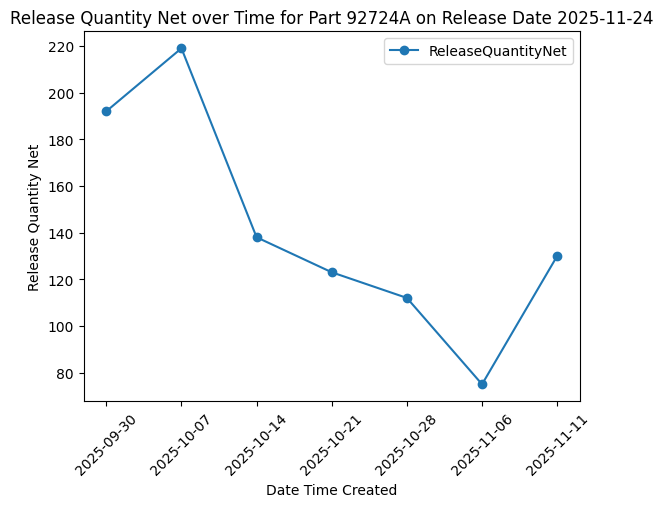

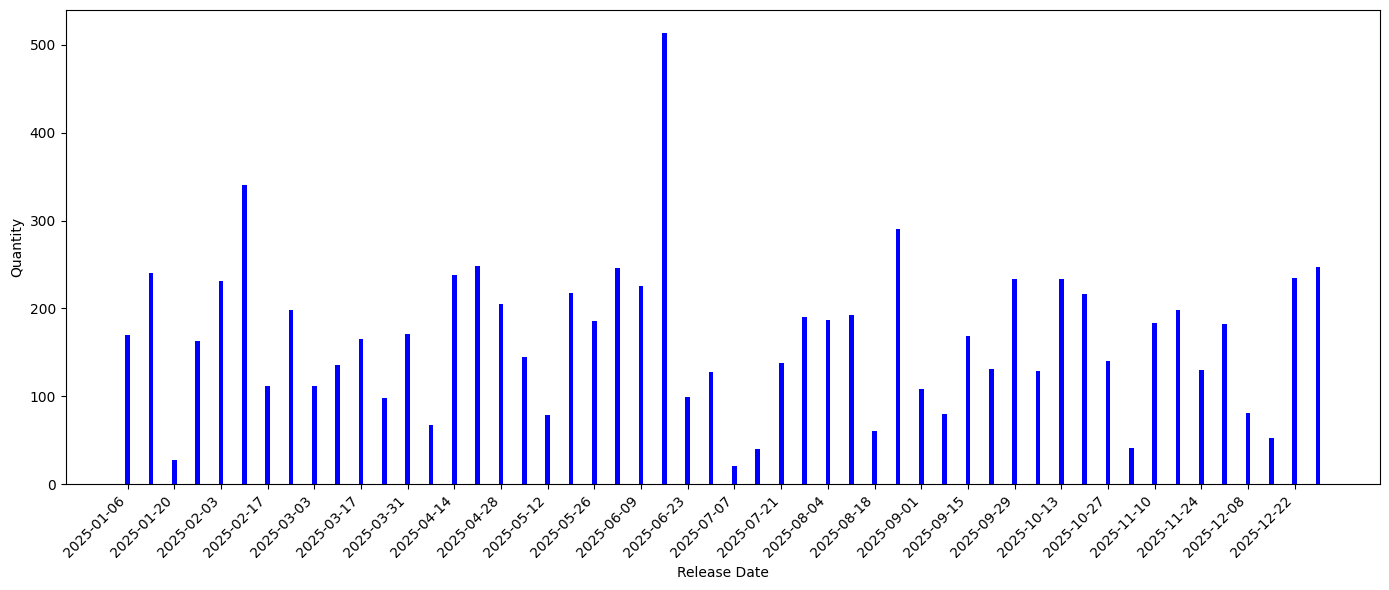

In [234]:
df_part_last = df_part.sort_values("DateTimeCreated").groupby("ReleaseDate").last().reset_index()
df_part_last = df_part_last.sort_values("ReleaseDate")
df_part_last["ReleaseDate"] = pd.to_datetime(df_part_last["ReleaseDate"])  # convert to datetime
fig, ax = plt.subplots(figsize=(14, 6))
data = df_part_last.iloc[-52:]
ax.bar(range(len(data)), data["ReleaseQuantityNet"], color="blue", width = 0.2)
ax.set_xticks(range(0, len(data), 2))  # show every 2nd tick
ax.set_xticklabels(data["ReleaseDate"].dt.strftime("%Y-%m-%d").iloc[::2], rotation=45, ha='right', )
ax.set_xlabel("Release Date")
ax.set_ylabel("Quantity")
plt.tight_layout()

In [266]:
df[
    (df["InternalPartNumber"] == "92724A")
    & (df["ReleaseDate"] == "2025-12-22")
].sort_values(by="HorizonIssueDate")[["Release", "OldRelease", "InternalPartNumber", "ReleaseDate", "HorizonIssueDate"]]

,Release,OldRelease,InternalPartNumber,ReleaseDate,HorizonIssueDate
50723,251028-53479-0002,251027-53307-0001,92724A,2025-12-22,2025-10-28
28433,251106-53687-0002,251103-53508-0001,92724A,2025-12-22,2025-11-06
55691,251111-53883-0002,251110-53714-0001,92724A,2025-12-22,2025-11-11
2291,251124-54276-0002,251117-53923-0001,92724A,2025-12-22,2025-11-24
27089,251202-54469-0002,251201-54302-0001,92724A,2025-12-22,2025-12-02
55290,251208-54682-0002,251202-54469-0002,92724A,2025-12-22,2025-12-08
19255,251215-54889-0002,251208-54682-0002,92724A,2025-12-22,2025-12-15


/var/folders/fj/lf41s2h17nbgr6r8vnlcyb4c0000gr/T/ipykernel_98625/3290211960.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_part["LeadTimeDays"] = (pd.to_datetime(df_part["ReleaseDate"]) - pd.to_datetime(df_part["DateTimeCreated"])).dt.days
/var/folders/fj/lf41s2h17nbgr6r8vnlcyb4c0000gr/T/ipykernel_98625/3290211960.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_part["final_count"] = df_part["ReleaseDate"].map(final_count)


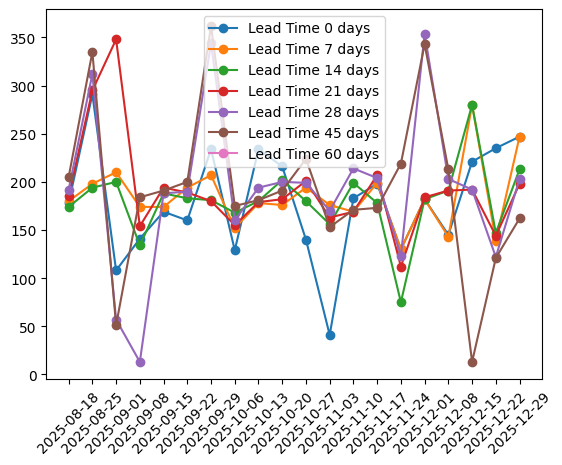

In [188]:
final_count = df_part_last.set_index("ReleaseDate")["ReleaseQuantityNet"].to_dict()
df_part["LeadTimeDays"] = (pd.to_datetime(df_part["ReleaseDate"]) - pd.to_datetime(df_part["DateTimeCreated"])).dt.days
df_part["final_count"] = df_part["ReleaseDate"].map(final_count)
sum_quantity = {}
for lead_time in [0, 7, 14, 21, 28, 45,  60]:
    df_part_lead_time = df_part[df_part["LeadTimeDays"] >lead_time]
    df_part_last = df_part_lead_time.sort_values("DateTimeCreated").groupby("ReleaseDate").last().reset_index()
    df_part_last = df_part_last.sort_values("ReleaseDate")
    # keep only the last 20 releases
    df_part_last = df_part_last.tail(20)
    plt.plot(df_part_last["ReleaseDate"], df_part_last["ReleaseQuantityNet"], marker = "o", label=f"Lead Time {lead_time} days")
    sum_quantity[lead_time] = df_part_last["ReleaseQuantityNet"].sum()
plt.xticks(rotation=45)
plt.legend()

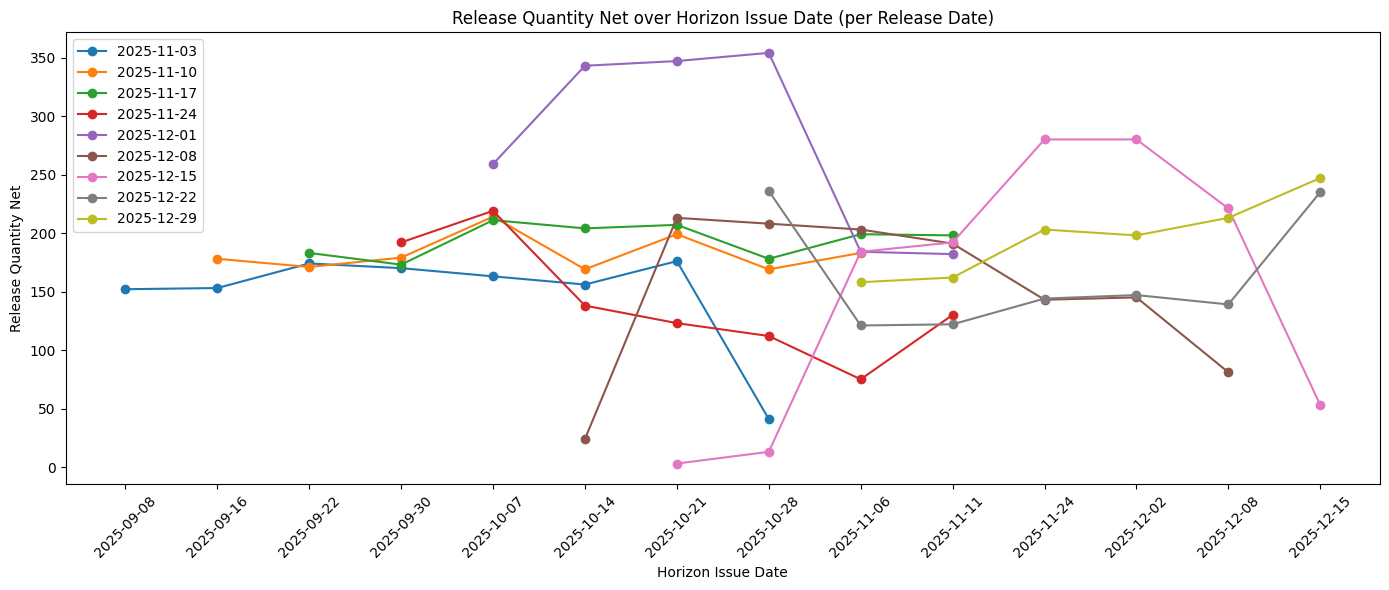

In [255]:
fig, ax = plt.subplots(figsize=(14, 6))
for release_date, group in df_part.sort_values("HorizonIssueDate").groupby("ReleaseDate"):
    if release_date < "2025-11-01": 
        continue # only plot for release dates before a certain date to avoid clutter
    ax.plot(group["HorizonIssueDate"], group["ReleaseQuantityNet"], marker="o", label=str(release_date)[:10])
ax.set_xlabel("Horizon Issue Date")
ax.set_ylabel("Release Quantity Net")
ax.set_title("Release Quantity Net over Horizon Issue Date (per Release Date)")
plt.xticks(rotation=45)
# Only show legend if not too many release dates
if df_part["ReleaseDate"].nunique() <= 20:
    ax.legend(title="Release Date", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.legend()

array([1.        , 1.05080268, 1.0529872 , 1.09489941, 1.14346678,
       1.10485674, 0.        ])

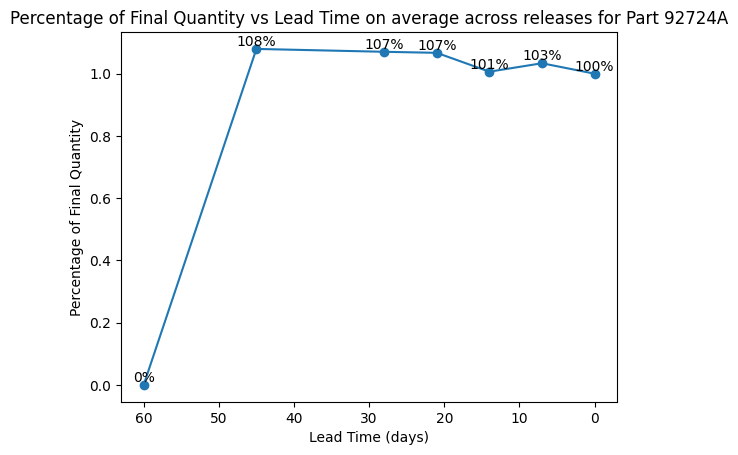

In [194]:
final_quntity = sum_quantity[0]
keys = list(sum_quantity.keys())
values = list(sum_quantity.values())/final_quntity
plt.plot(keys, values, marker = "o")
for k, v in zip(keys, values):
    plt.text(k, v, f"{100*v:.0f}%", ha='center', va='bottom')
plt.xlabel("Lead Time (days)")
plt.ylabel("Percentage of Final Quantity")
plt.title("Percentage of Final Quantity vs Lead Time on average across releases for Part 92724A")
plt.gca().invert_xaxis()  # Invert x-axis to show lead time decreasing from left to right

In [177]:
values

array([1.        , 1.05080268, 1.0529872 , 1.09489941, 1.14346678,
       1.10485674, 0.        ])

/var/folders/fj/lf41s2h17nbgr6r8vnlcyb4c0000gr/T/ipykernel_98625/3542439355.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_part["LeadTimeDays"] = (pd.to_datetime(df_part["ReleaseDate"]) - pd.to_datetime(df_part["DateTimeCreated"])).dt.days
/var/folders/fj/lf41s2h17nbgr6r8vnlcyb4c0000gr/T/ipykernel_98625/3542439355.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_part["LeadTimeDays"] = (df_part["LeadTimeDays"] / 7).round() * 7
/var/folders/fj/lf41s2h17nbgr6r8vnlcyb4c0000gr/T/ipykernel_98625/354

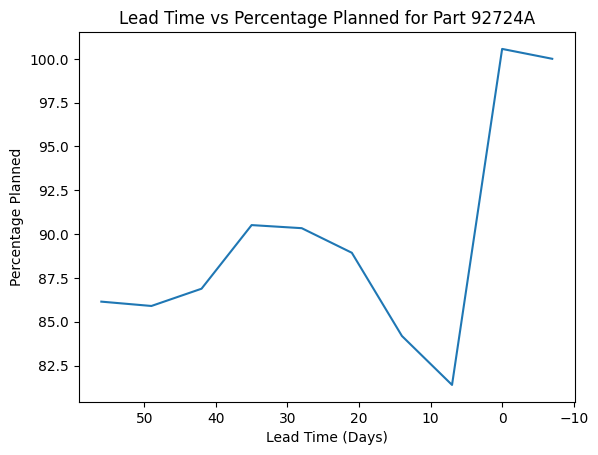

In [ ]:
df_part_agg = df_part.groupby("LeadTimeDays").agg(
    final_count=pd.NamedAgg(column="final_count", aggfunc="sum"),
    ReleaseQuantityNet=pd.NamedAgg(column="ReleaseQuantityNet", aggfunc="sum"),
).reset_index()
df_part_agg["percentagePlanned"] = df_part_agg["ReleaseQuantityNet"] / df_part_agg["final_count"] * 100
plt.plot(df_part_agg["LeadTimeDays"], df_part_agg["percentagePlanned"])
plt.xlabel("Lead Time (Days)")
plt.ylabel("Percentage Planned")
plt.title("Lead Time vs Percentage Planned for Part 92724A")
# inverse x-axis
plt.gca().invert_xaxis()

In [145]:
df_part_agg

,LeadTimeDays,final_count,ReleaseQuantityNet,percentagePlanned
0,-7,467,467,100.000000
1,-4,812,812,100.000000
2,-2,903,903,100.000000
3,-1,1451,1451,100.000000
4,0,23163,23325,100.699391
5,3,230,213,92.608696
6,4,577,736,127.556326
7,5,3332,1189,35.684274
8,6,5961,5202,87.267237
9,7,23044,19735,85.640514


In [136]:
df_part_release.sort_values("DateTimeCreated")

,Id,NextReleaseDate,OldHorizonIssueDate,HorizonIssueDate,ReleaseDate,DateTimeCreated,InternalPartNumber,KeytoTRLP,ABCCode,Release,ReleaseQuantityNet,ReleaseQuantityCum,OldRelease,OldQuantity,ShippedQ,LeadTimeDays,final_count,percentagePlanned
25405,3127_2025-11-24 00:00:00_2025-09-30 00:00:00,2025-11-25,2025-09-29,2025-09-30,2025-11-24,2025-09-30,92724A,3127,NaN,250930-52650-0002,192,30942,250929-52490-0001,32.0,NaN,55,130,147.692308
24797,3127_2025-11-24 00:00:00_2025-10-07 00:00:00,2025-11-25,2025-10-06,2025-10-07,2025-11-24,2025-10-07,92724A,3127,NaN,251007-52862-0002,219,31156,251006-52686-0001,37.0,NaN,48,130,168.461538
20199,3127_2025-11-24 00:00:00_2025-10-14 00:00:00,2025-11-25,2025-10-13,2025-10-14,2025-11-24,2025-10-14,92724A,3127,NaN,251014-53065-0002,138,31152,251013-52950-0001,23.0,NaN,41,130,106.153846
18944,3127_2025-11-24 00:00:00_2025-10-21 00:00:00,2025-11-25,2025-10-20,2025-10-21,2025-11-24,2025-10-21,92724A,3127,NaN,251021-53269-0002,123,31064,251020-53103-0001,21.0,NaN,34,130,94.615385
50747,3127_2025-11-24 00:00:00_2025-10-28 00:00:00,2025-11-25,2025-10-27,2025-10-28,2025-11-24,2025-10-28,92724A,3127,NaN,251028-53479-0002,112,30970,251027-53307-0001,112.0,NaN,27,130,86.153846
28333,3127_2025-11-24 00:00:00_2025-11-06 00:00:00,2025-11-25,2025-10-28,2025-11-06,2025-11-24,2025-11-06,92724A,3127,NaN,251106-53687-0002,75,31047,251028-53479-0002,112.0,NaN,18,130,57.692308
55750,3127_2025-11-24 00:00:00_2025-11-11 00:00:00,2025-11-25,2025-11-10,2025-11-11,2025-11-24,2025-11-11,92724A,3127,NaN,251111-53883-0002,130,31055,251110-53714-0001,130.0,NaN,13,130,100.000000


In [111]:
df.groupby(["InternalPartNumber"]).agg(
    release_count=pd.NamedAgg(column="ReleaseDate", aggfunc="nunique"),
    release_max=pd.NamedAgg(column="ReleaseDate", aggfunc="max"),
    release_min=pd.NamedAgg(column="ReleaseDate", aggfunc="min"),
).sort_values("release_count", ascending=False)

,release_count,release_max,release_min
InternalPartNumber,,,
99090CW,322,2025-12-30,2023-12-04
99146CW,321,2025-12-29,2023-12-04
92404A,240,2025-12-29,2020-11-02
99090AW,225,2025-12-30,2023-12-04
99146AW,223,2025-12-29,2023-12-04
...,...,...,...
99097JS,1,2021-07-30,2021-07-30
99146CBRS,1,2023-05-03,2023-05-03
99097LS,1,2023-05-10,2023-05-10


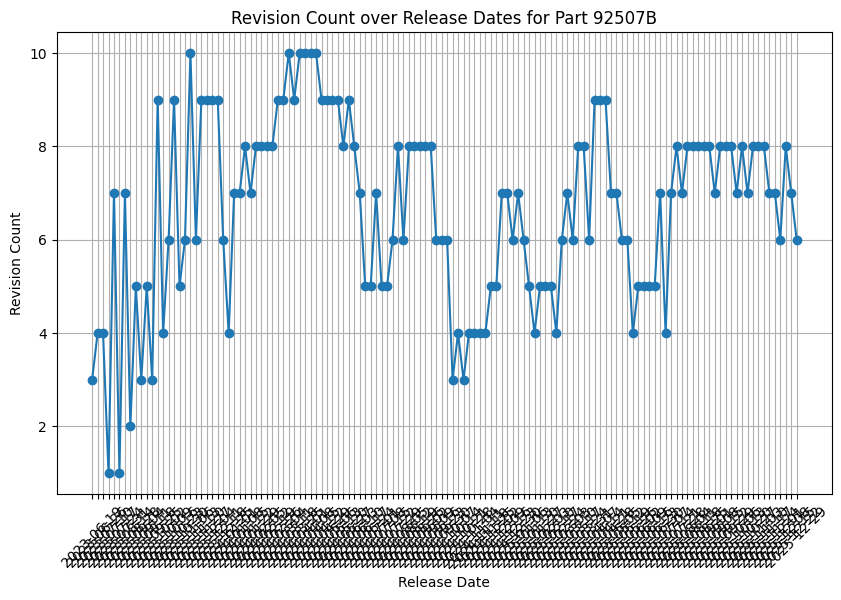

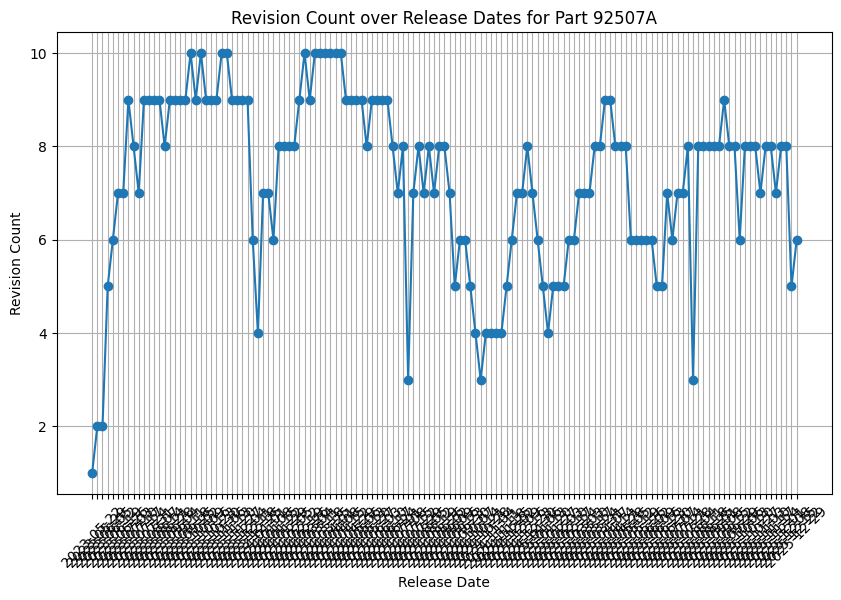

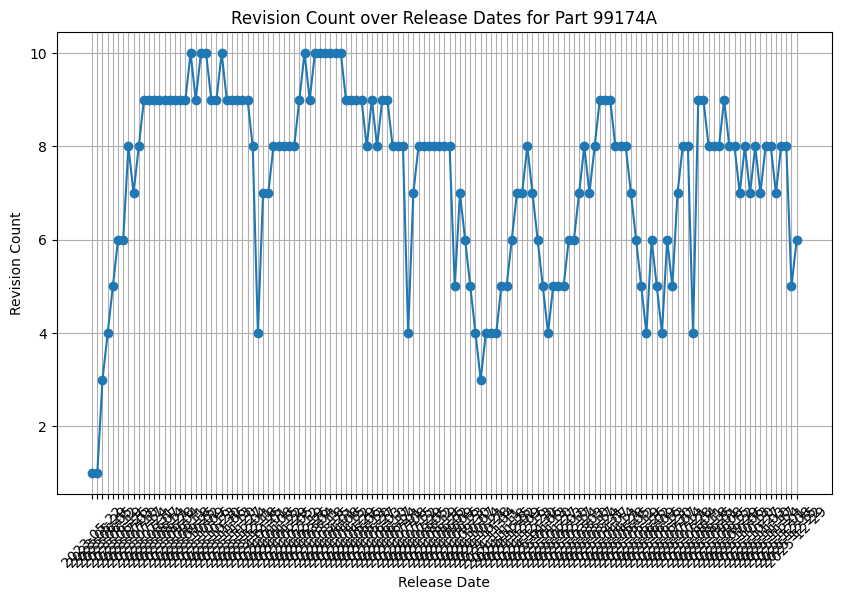

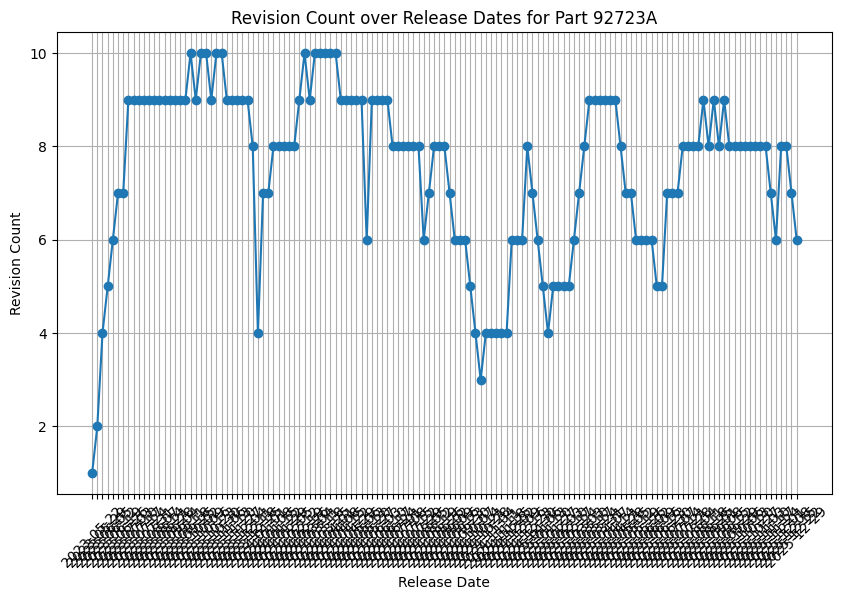

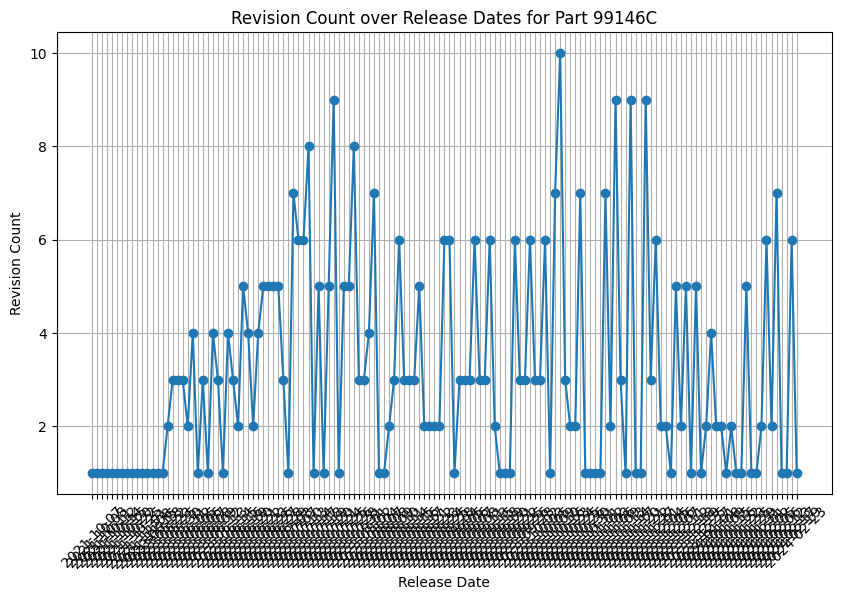

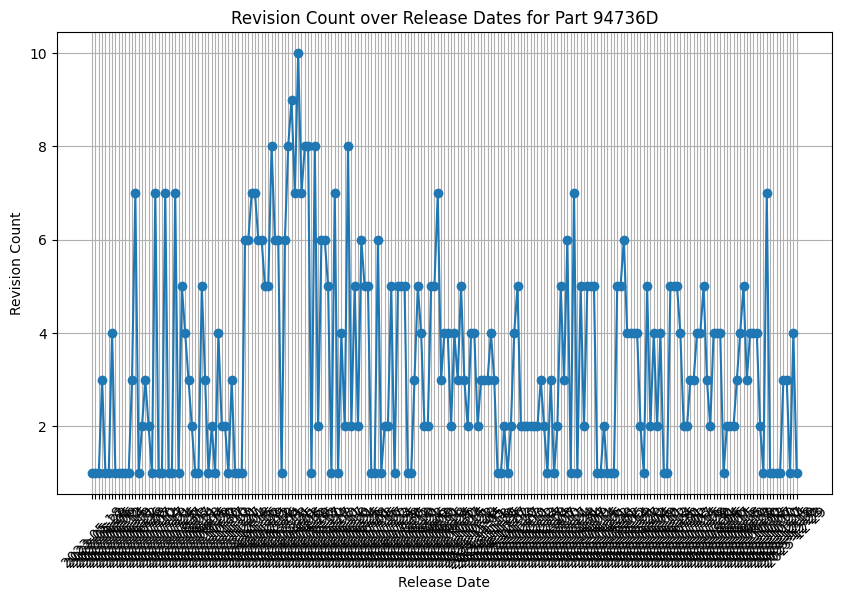

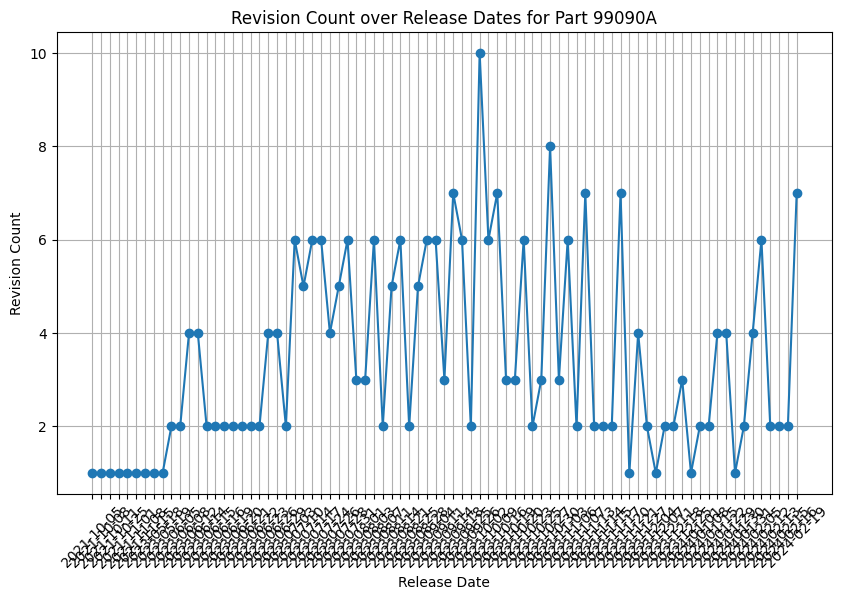

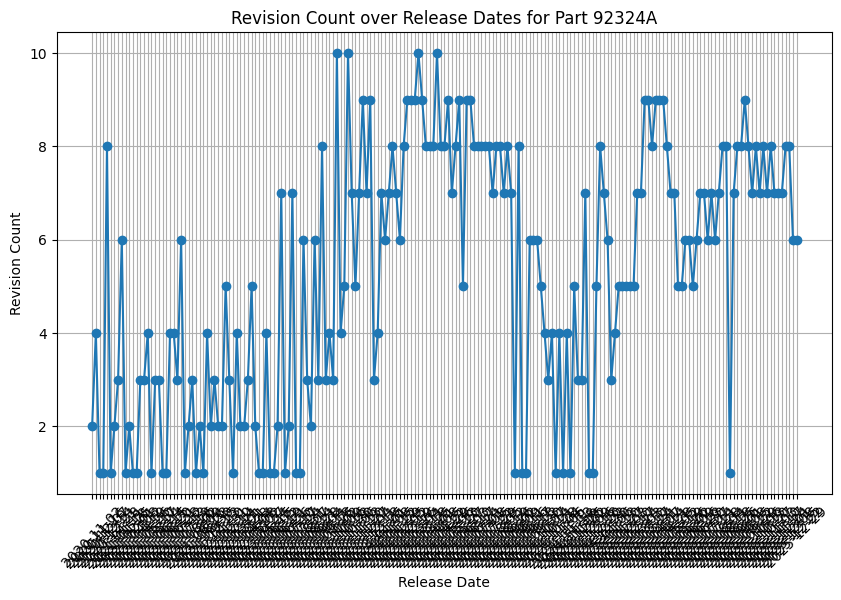

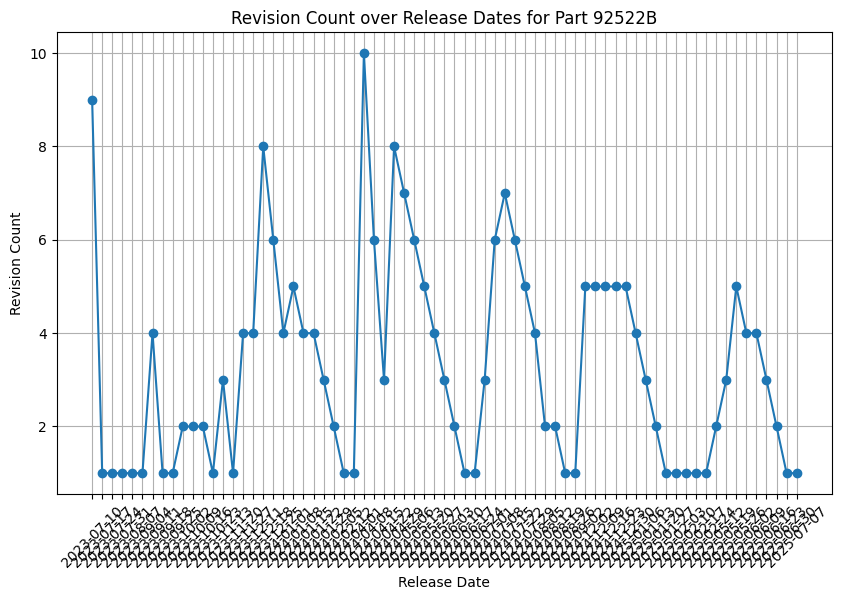

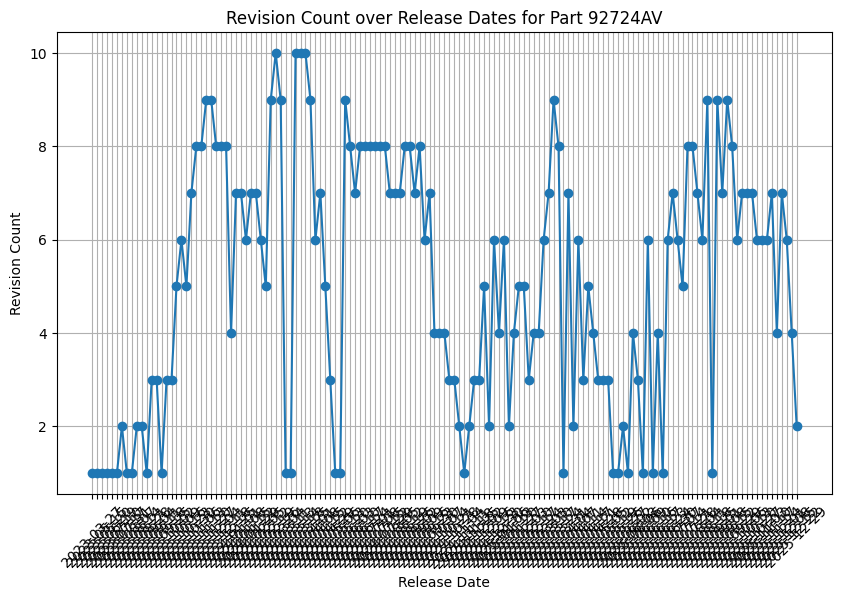

In [115]:
revision_counts = df.groupby(["InternalPartNumber", "ReleaseDate"]).agg(
    revision_count=pd.NamedAgg(column="DateTimeCreated", aggfunc="count"),
).sort_values("revision_count", ascending=False).reset_index()
parts = revision_counts["InternalPartNumber"].unique()
for part in parts[:10]:
    revision_counts_part = revision_counts[revision_counts["InternalPartNumber"] == part].sort_values("ReleaseDate")
    if len(revision_counts_part) > 1:
        plt.figure(figsize=(10, 6))
        plt.plot(revision_counts_part["ReleaseDate"], revision_counts_part["revision_count"], marker='o')
        plt.title(f"Revision Count over Release Dates for Part {part}")
        plt.xlabel("Release Date")
        plt.ylabel("Revision Count")
        plt.xticks(rotation=45)
        plt.grid()
        plt.show()

In [113]:
revision_counts_part

,InternalPartNumber,ReleaseDate,revision_count
16020,99097LS,2023-05-10,1


In [36]:
df.loc[df["Release"] == "240513-35045-0002"]

,Id,NextReleaseDate,OldHorizonIssueDate,HorizonIssueDate,ReleaseDate,DateTimeCreated,LineId,InternalPartNumber,KeytoTRLP,ABCCode,BillToCustomer,CustomerName,Release,ReleaseTimeHHMM,ReleaseQuantityNet,ReleaseQuantityCum,OldRelease,OldQuantity,ShippedQ,SalePrice,StdCost,ForecastQ,VarbwForecastShipmentQty,VarbwForecastShipmentPer,VarbwForecastShipmentPerabs,VarbwForecastShipmentSales,VarbwForecastShipmentStd,Year,Month,Day
6080,3125_2024-05-13 00:00:00_2024-05-13 00:00:00,2024-05-14,2024-05-06,2024-05-13,2024-05-13,2024-05-13,4,92507A,3125,NaN,CUST-02,Customer 02,240513-35045-0002,0,656,26073,240506-34474-0002,544.0,32.0,99.99,99.99,656.0,-624.0,-0.95,0.95,-44408.71,-31519.01,2024,5,13
6081,3524_2024-06-14 00:00:00_2024-05-13 00:00:00,2024-06-17,2024-05-06,2024-05-13,2024-06-14,2024-05-13,4,99146CW,3524,A,CUST-02,Customer 02,240513-35045-0002,0,144,5794,240506-34358-0001,63.0,112.0,99.99,99.99,NaN,NaN,1.00,1.00,NaN,NaN,2024,5,13
6082,3125_2024-06-24 00:00:00_2024-05-13 00:00:00,2024-06-25,2024-05-06,2024-05-13,2024-06-24,2024-05-13,4,92507A,3125,NaN,CUST-02,Customer 02,240513-35045-0002,0,1136,29449,240506-34474-0002,1072.0,NaN,99.99,99.99,192.0,NaN,1.00,1.00,NaN,NaN,2024,5,13
6083,3193_2024-06-24 00:00:00_2024-05-13 00:00:00,2024-06-25,2024-05-06,2024-05-13,2024-06-24,2024-05-13,4,92723D,3193,NaN,CUST-02,Customer 02,240513-35045-0002,0,10,652,240506-34474-0002,10.0,NaN,99.99,99.99,NaN,NaN,1.00,1.00,NaN,NaN,2024,5,13
6084,3527_2024-06-12 00:00:00_2024-05-13 00:00:00,2024-06-13,2024-05-06,2024-05-13,2024-06-12,2024-05-13,4,99146KW,3527,A,CUST-02,Customer 02,240513-35045-0002,0,132,2111,240506-34359-0001,40.0,16.0,99.99,99.99,NaN,NaN,1.00,1.00,NaN,NaN,2024,5,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6540,3524_2024-06-12 00:00:00_2024-05-13 00:00:00,2024-06-13,2024-05-06,2024-05-13,2024-06-12,2024-05-13,4,99146CW,3524,A,CUST-02,Customer 02,240513-35045-0002,0,96,5506,240506-34358-0001,64.0,NaN,99.99,99.99,NaN,NaN,1.00,1.00,NaN,NaN,2024,5,13
6541,3530_2024-06-10 00:00:00_2024-05-13 00:00:00,2024-06-11,2024-05-06,2024-05-13,2024-06-10,2024-05-13,4,99090CW,3530,A,CUST-02,Customer 02,240513-35045-0002,0,387,5843,240506-34474-0002,318.0,136.0,99.99,99.99,184.0,-48.0,-0.26,0.26,-4823.66,-3016.30,2024,5,13
6542,2459_2024-05-24 00:00:00_2024-05-13 00:00:00,2024-05-27,2024-05-06,2024-05-13,2024-05-24,2024-05-13,4,99100B,2459,B,CUST-02,Customer 02,240513-35045-0002,0,48,5232,240506-34474-0002,48.0,NaN,99.99,99.99,NaN,NaN,1.00,1.00,NaN,NaN,2024,5,13
6543,2458_2024-07-08 00:00:00_2024-05-13 00:00:00,2024-07-09,NaT,2024-05-13,2024-07-08,2024-05-13,4,99100D,2458,C,CUST-02,Customer 02,240513-35045-0002,0,32,3415,NaN,NaN,NaN,99.99,99.99,NaN,NaN,1.00,1.00,NaN,NaN,2024,5,13


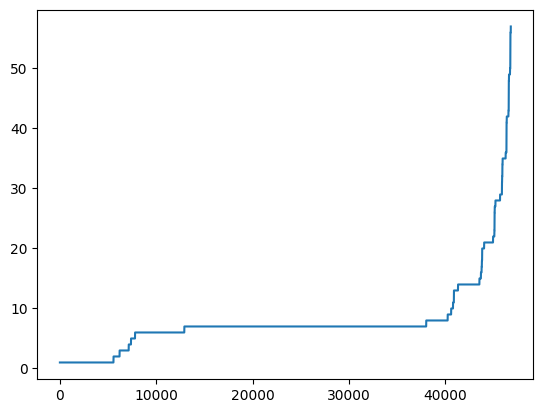

In [338]:
df2 = pd.read_csv("celonis_data_forecast.csv")

In [339]:
df2 = df2.dropna(subset = ["LightGBMForecast"])
df2.shape

(2502, 32)

In [280]:
df2[["LightGBMForecast", "ProphetForecast", "ReleaseDate", "ReleaseQuantityNet", "InternalPartNumber"]].sample(6)

,LightGBMForecast,ProphetForecast,ReleaseDate,ReleaseQuantityNet,InternalPartNumber
27787,35.9,34.1,2026-01-19,32,99174E
29278,159.4,344.3,2026-02-25,108,99146CW
14110,100.8,261.6,2026-02-11,112,99090AW
20664,111.7,94.9,2026-02-09,320,99174B
513,34.3,47.7,2026-01-23,32,99097KW
34596,144.7,277.3,2026-02-18,144,99090CW


In [281]:
df2.groupby(["ReleaseDate", "InternalPartNumber"]).count()

Id  LightGBMForecast  ProphetForecast  \
ReleaseDate InternalPartNumber                                          
2026-01-05  92324A               1                 1                1   
            92324B               1                 1                1   
            92404A               2                 2                2   
            92507A               2                 2                2   
            92507B               3                 3                3   
...                             ..               ...              ...   
2026-02-27  99099A               1                 1                1   
            99100A               1                 1                0   
            99146BW              1                 1                1   
            99146CW              1                 1                1   
            99146M               6                 6                6   

                                NextReleaseDate  OldHorizonIssueDate  \
ReleaseDate InternalPartNumber                                         
2026-01-05  92324A                            1                    0   
            92324B                            1                    0   
            92404A                            2                    2   
            92507A                            2                    2   
            92507B                            3                    3   
...                                         ...                  ...   
2026-02-27  99099A                            1                    0   
            99100A                            1                    0   
            99146BW                           1                    1   
            99146CW                           1                    1   
            99146M                            6                    6   

                                HorizonIssueDate  DateTimeCreated  LineId  \
ReleaseDate InternalPartNumber                                              
2026-01-05  92324A                             1                1       1   
            92324B                             1                1       1   
            92404A                             2                2       2   
            92507A                             2                2       2   
            92507B                             3                3       3   
...                                          ...              ...     ...   
2026-02-27  99099A                             1                1       1   
            99100A                             1                1       1   
            99146BW                            1                1       1   
            99146CW                            1                1       1   
            99146M                             6                6       6   

                                KeytoTRLP  ABCCode  BillToCustomer  \
ReleaseDate InternalPartNumber                                       
2026-01-05  92324A                      1        0               1   
            92324B                      1        0               1   
            92404A                      2        0               2   
            92507A                      2        0               2   
            92507B                      3        0               3   
...                                   ...      ...             ...   
2026-02-27  99099A                      1        1               1   
            99100A                      1        1               1   
            99146BW                     1        1               1   
            99146CW                     1        1               1   
            99146M                      6        6               6   

                                CustomerName  Release  ReleaseTimeHHMM  \
ReleaseDate InternalPartNumber                                           
2026-01-05  92324A                         1        1                1   
          

In [ ]:
df2.loc[(df2["ReleaseDate"] == "2026-01-05" ) &(df2["InternalPartNumber"] == "92507B"), ["", "", ]]

,Id,LightGBMForecast,ProphetForecast,NextReleaseDate,OldHorizonIssueDate,HorizonIssueDate,ReleaseDate,DateTimeCreated,LineId,InternalPartNumber,KeytoTRLP,ABCCode,BillToCustomer,CustomerName,Release,ReleaseTimeHHMM,ReleaseQuantityNet,ReleaseQuantityCum,OldRelease,OldQuantity,ShippedQ,SalePrice,StdCost,ForecastQ,VarbwForecastShipmentQty,VarbwForecastShipmentPer,VarbwForecastShipmentPerabs,VarbwForecastShipmentSales,VarbwForecastShipmentStd,Year,Month,Day
2646,3126_2026-01-05 00:00:00_2025-11-24 00:00:00,48.4,77.0,2026-01-06,2025-11-11,2025-11-24,2026-01-05,2025-11-24,4,92507B,3126,NaN,CUST-02,Customer 02,251124-54276-0002,0,64,10830,251111-53883-0002,48.0,NaN,99.99,99.99,NaN,NaN,1.0,1.0,NaN,NaN,2025,11,24
2782,3126_2026-01-05 00:00:00_2025-12-02 00:00:00,48.4,77.0,2026-01-06,2025-12-01,2025-12-02,2026-01-05,2025-12-02,4,92507B,3126,NaN,CUST-02,Customer 02,251202-54469-0002,0,48,10750,251201-54299-0001,10.0,NaN,99.99,99.99,NaN,NaN,1.0,1.0,NaN,NaN,2025,12,2
2918,3126_2026-01-05 00:00:00_2025-11-11 00:00:00,48.4,77.0,2026-01-06,2025-11-10,2025-11-11,2026-01-05,2025-11-11,4,92507B,3126,NaN,CUST-02,Customer 02,251111-53883-0002,0,48,10800,251110-53712-0001,10.0,NaN,99.99,99.99,NaN,NaN,1.0,1.0,NaN,NaN,2025,11,11


In [300]:
df3 = df2.dropna(subset = ["ForecastQ", "LightGBMForecast", "ProphetForecast"])
df3.sample()[["ForecastQ", "LightGBMForecast", "ProphetForecast", "ReleaseDate", "InternalPartNumber", "ReleaseQuantityNet"]]

,ForecastQ,LightGBMForecast,ProphetForecast,ReleaseDate,InternalPartNumber,ReleaseQuantityNet
53213,12.0,8.4,0.0,2026-02-02,94730D,12


In [328]:
df3_last = df3.sort_values("HorizonIssueDate").groupby(["ReleaseDate", "InternalPartNumber"]).last().reset_index()
df2_last = df2.sort_values("HorizonIssueDate").groupby(["ReleaseDate", "InternalPartNumber"]).last().reset_index()
df2_last.shape, df3_last.shape

((734, 32), (171, 32))

In [344]:
# calculate errors for ForecastQ", "LightGBMForecast", "ProphetForecast
df2_last["Error_LightGBM"] = df2_last["ReleaseQuantityNet"] - df2_last["LightGBMForecast"]
df2_last["Error_Prophet"] = df2_last["ReleaseQuantityNet"] - df2_last["ProphetForecast"]
df2_last["Error_LightGBM"].abs().sum()/df2_last["ReleaseQuantityNet"].abs().sum(), df2_last["Error_Prophet"].abs().sum()/df2_last["ReleaseQuantityNet"].abs().sum()

(np.float64(0.5066261506837072), np.float64(0.8207507373313075))

In [355]:
pd.date_range(start ="2026-01-05", periods = 8, freq = "W-MON")

DatetimeIndex(['2026-01-05', '2026-01-12', '2026-01-19', '2026-01-26',
               '2026-02-02', '2026-02-09', '2026-02-16', '2026-02-23'],
              dtype='datetime64[ns]', freq='W-MON')

In [356]:
df2_last["ReleaseDate"].unique()

array(['2026-01-05', '2026-01-12', '2026-01-13', '2026-01-14',
       '2026-01-15', '2026-01-16', '2026-01-19', '2026-01-20',
       '2026-01-21', '2026-01-22', '2026-01-23', '2026-01-26',
       '2026-01-27', '2026-01-28', '2026-01-29', '2026-01-30',
       '2026-02-02', '2026-02-03', '2026-02-04', '2026-02-05',
       '2026-02-06', '2026-02-09', '2026-02-10', '2026-02-11',
       '2026-02-12', '2026-02-13', '2026-02-16', '2026-02-17',
       '2026-02-18', '2026-02-19', '2026-02-20', '2026-02-23',
       '2026-02-24', '2026-02-25', '2026-02-26', '2026-02-27'],
      dtype=object)

In [330]:
# calculate errors for ForecastQ", "LightGBMForecast", "ProphetForecast
df3_last["Error_ForecastQ"] = df3_last["ReleaseQuantityNet"] - df3_last["ForecastQ"]
df3_last["Error_LightGBM"] = df3_last["ReleaseQuantityNet"] - df3_last["LightGBMForecast"]
df3_last["Error_Prophet"] = df3_last["ReleaseQuantityNet"] - df3_last["ProphetForecast"]
df3_last["Error_ForecastQ"].abs().sum()/df3_last["ReleaseQuantityNet"].abs().sum(), df3_last["Error_LightGBM"].abs().sum()/df3_last["ReleaseQuantityNet"].abs().sum(), df3_last["Error_Prophet"].abs().sum()/df3_last["ReleaseQuantityNet"].abs().sum()

(np.float64(0.028156595344462732),
 np.float64(0.6135845285680696),
 np.float64(0.7748354102986127))

In [331]:
df3_last.shape

(171, 35)

In [332]:
df3_last.loc[df3_last["Error_ForecastQ"] < 1].sample()[["ForecastQ", "LightGBMForecast", "ProphetForecast", "ReleaseDate", "InternalPartNumber", "ReleaseQuantityNet"]]

,ForecastQ,LightGBMForecast,ProphetForecast,ReleaseDate,InternalPartNumber,ReleaseQuantityNet
25,4.0,8.9,15.0,2026-01-20,94729B,4


In [333]:
df3_last.loc[df3_last["Error_ForecastQ"] < 1].shape

(165, 35)

In [336]:
df3_last.loc[df3_last["Error_ForecastQ"] > 1, ["ForecastQ", "LightGBMForecast", "ProphetForecast", "ReleaseDate", "InternalPartNumber", "ReleaseQuantityNet"]]

,ForecastQ,LightGBMForecast,ProphetForecast,ReleaseDate,InternalPartNumber,ReleaseQuantityNet
8,179.0,131.7,174.2,2026-01-12,92723A,242
159,40.0,60.6,64.5,2026-02-23,92404A,160
160,368.0,757.0,59.1,2026-02-23,92507A,464
161,14.0,27.5,43.0,2026-02-23,92507E,18
162,202.0,147.7,37.6,2026-02-23,92723A,302
164,416.0,661.2,5.9,2026-02-23,99174A,432


In [341]:
df2.loc[(df2["InternalPartNumber"] == "92723A") & (df2["ReleaseDate"]  == "2026-02-23")]

,Id,LightGBMForecast,ProphetForecast,NextReleaseDate,OldHorizonIssueDate,HorizonIssueDate,ReleaseDate,DateTimeCreated,LineId,InternalPartNumber,KeytoTRLP,ABCCode,BillToCustomer,CustomerName,Release,ReleaseTimeHHMM,ReleaseQuantityNet,ReleaseQuantityCum,OldRelease,OldQuantity,ShippedQ,SalePrice,StdCost,ForecastQ,VarbwForecastShipmentQty,VarbwForecastShipmentPer,VarbwForecastShipmentPerabs,VarbwForecastShipmentSales,VarbwForecastShipmentStd,Year,Month,Day
59115,3130_2026-02-23 00:00:00_2026-02-16 00:00:00,147.7,37.6,2026-02-24,2026-02-09,2026-02-16,2026-02-23,2026-02-16,4,92723A,3130,NaN,CUST-02,Customer 02,260216-56689-0002,0,302,32066,260209-56466-0002,244.0,NaN,99.99,99.99,202.0,NaN,1.0,1.0,NaN,NaN,2026,2,16
59176,3130_2026-02-23 00:00:00_2026-01-20 00:00:00,147.7,37.6,2026-02-24,2026-01-19,2026-01-20,2026-02-23,2026-01-20,4,92723A,3130,NaN,CUST-02,Customer 02,260120-55859-0002,0,234,32252,260119-55786-0001,47.0,NaN,99.99,99.99,202.0,NaN,1.0,1.0,NaN,NaN,2026,1,20
59180,3130_2026-02-23 00:00:00_2026-02-02 00:00:00,147.7,37.6,2026-02-24,2026-01-27,2026-02-02,2026-02-23,2026-02-02,4,92723A,3130,NaN,CUST-02,Customer 02,260202-56275-0002,0,247,31842,260127-56067-0002,235.0,NaN,99.99,99.99,202.0,NaN,1.0,1.0,NaN,NaN,2026,2,2
59189,3130_2026-02-23 00:00:00_2026-02-10 00:00:00,147.7,37.6,2026-02-24,2026-02-02,2026-02-09,2026-02-23,2026-02-10,4,92723A,3130,NaN,CUST-02,Customer 02,260209-56466-0002,0,244,32043,260202-56275-0002,247.0,NaN,99.99,99.99,202.0,NaN,1.0,1.0,NaN,NaN,2026,2,10
59200,3130_2026-02-23 00:00:00_2026-01-13 00:00:00,147.7,37.6,2026-02-24,2026-01-12,2026-01-13,2026-02-23,2026-01-13,4,92723A,3130,NaN,CUST-02,Customer 02,260113-55660-0002,0,232,32075,260112-55504-0001,47.0,NaN,99.99,99.99,202.0,NaN,1.0,1.0,NaN,NaN,2026,1,13
59203,3130_2026-02-23 00:00:00_2026-02-19 00:00:00,147.7,37.6,2026-02-24,2026-02-16,2026-02-19,2026-02-23,2026-02-19,4,92723A,3130,NaN,CUST-02,Customer 02,260219-56723-0002,0,302,32066,260216-56689-0002,302.0,NaN,99.99,99.99,202.0,NaN,1.0,1.0,NaN,NaN,2026,2,19
59212,3130_2026-02-23 00:00:00_2026-01-05 00:00:00,147.7,37.6,2026-02-24,2025-12-29,2026-01-05,2026-02-23,2026-01-05,4,92723A,3130,NaN,CUST-02,Customer 02,260105-55450-0002,0,239,32236,251229-55109-0001,48.0,NaN,99.99,99.99,202.0,NaN,1.0,1.0,NaN,NaN,2026,1,5
59304,3130_2026-02-23 00:00:00_2026-01-27 00:00:00,147.7,37.6,2026-02-24,2026-01-26,2026-01-27,2026-02-23,2026-01-27,4,92723A,3130,NaN,CUST-02,Customer 02,260127-56067-0002,0,235,32250,260126-55894-0001,222.0,NaN,99.99,99.99,202.0,NaN,1.0,1.0,NaN,NaN,2026,1,27


In [342]:
df2.loc[(df2["InternalPartNumber"] == "92723A") & (df2["ReleaseDate"]  == "2026-02-16")]

,Id,LightGBMForecast,ProphetForecast,NextReleaseDate,OldHorizonIssueDate,HorizonIssueDate,ReleaseDate,DateTimeCreated,LineId,InternalPartNumber,KeytoTRLP,ABCCode,BillToCustomer,CustomerName,Release,ReleaseTimeHHMM,ReleaseQuantityNet,ReleaseQuantityCum,OldRelease,OldQuantity,ShippedQ,SalePrice,StdCost,ForecastQ,VarbwForecastShipmentQty,VarbwForecastShipmentPer,VarbwForecastShipmentPerabs,VarbwForecastShipmentSales,VarbwForecastShipmentStd,Year,Month,Day
54845,3130_2026-02-16 00:00:00_2026-02-16 00:00:00,135.2,89.8,2026-02-17,2026-02-09,2026-02-16,2026-02-16,2026-02-16,4,92723A,3130,NaN,CUST-02,Customer 02,260216-56689-0002,0,139,31764,260209-56466-0002,217.0,20.0,99.99,99.99,139.0,-119.0,-0.86,0.86,-7433.04,-6261.76,2026,2,16
54932,3130_2026-02-16 00:00:00_2026-01-20 00:00:00,135.2,89.8,2026-02-17,2026-01-19,2026-01-20,2026-02-16,2026-01-20,4,92723A,3130,NaN,CUST-02,Customer 02,260120-55859-0002,0,238,32018,260119-55786-0001,140.0,20.0,99.99,99.99,139.0,-119.0,-0.86,0.86,-7433.04,-6261.76,2026,1,20
54936,3130_2026-02-16 00:00:00_2026-02-02 00:00:00,135.2,89.8,2026-02-17,2026-01-27,2026-02-02,2026-02-16,2026-02-02,4,92723A,3130,NaN,CUST-02,Customer 02,260202-56275-0002,0,193,31595,260127-56067-0002,231.0,20.0,99.99,99.99,139.0,-119.0,-0.86,0.86,-7433.04,-6261.76,2026,2,2
54952,3130_2026-02-16 00:00:00_2026-02-10 00:00:00,135.2,89.8,2026-02-17,2026-02-02,2026-02-09,2026-02-16,2026-02-10,4,92723A,3130,NaN,CUST-02,Customer 02,260209-56466-0002,0,217,31799,260202-56275-0002,193.0,20.0,99.99,99.99,139.0,-119.0,-0.86,0.86,-7433.04,-6261.76,2026,2,10
54961,3130_2026-02-16 00:00:00_2026-01-13 00:00:00,135.2,89.8,2026-02-17,2026-01-12,2026-01-13,2026-02-16,2026-01-13,4,92723A,3130,NaN,CUST-02,Customer 02,260113-55660-0002,0,197,31843,260112-55504-0001,40.0,20.0,99.99,99.99,139.0,-119.0,-0.86,0.86,-7433.04,-6261.76,2026,1,13
54966,3130_2026-02-16 00:00:00_2026-01-05 00:00:00,135.2,89.8,2026-02-17,2025-12-29,2026-01-05,2026-02-16,2026-01-05,4,92723A,3130,NaN,CUST-02,Customer 02,260105-55450-0002,0,198,31997,251229-55109-0001,40.0,20.0,99.99,99.99,139.0,-119.0,-0.86,0.86,-7433.04,-6261.76,2026,1,5
55076,3130_2026-02-16 00:00:00_2026-01-27 00:00:00,135.2,89.8,2026-02-17,2026-01-26,2026-01-27,2026-02-16,2026-01-27,4,92723A,3130,NaN,CUST-02,Customer 02,260127-56067-0002,0,231,32015,260126-55894-0001,130.0,20.0,99.99,99.99,139.0,-119.0,-0.86,0.86,-7433.04,-6261.76,2026,1,27


In [357]:
# Ikigai SDK
from ikigai import Ikigai
# Standard library
import warnings

# Third-party
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import urllib3
import yaml
from utils import EXPLAINABILITY_METRICS_CONTEXT, app_info, upload_dataset, build_or_update_flow, run_flow



In [360]:
# ── Credentials ──────────────────────────────────────────────────────────
with open("key_prod.yaml", "r") as file:
    keys = yaml.safe_load(file)

API_KEY = keys["API_KEY"]
BASE_URL = keys["BASE_URL"]
USER_EMAIL = keys["USER_EMAIL"]

headers = {"User": USER_EMAIL, "Api-key": API_KEY}
ikigai = Ikigai(USER_EMAIL, API_KEY, BASE_URL)
app_name = "Celonis PoC"
try:
    app = ikigai.apps[app_name]
except RuntimeError:
    app = ikigai.app.new(name=app_name).build()




In [362]:
aux = app.datasets["aux"].df()

In [ ]:
aux

,date,InternalPartNumber,ABCCode,identifier,value
0,2023-05-30,92324A,Unknown,lead_0,200.0
1,2023-05-30,92324A,B,lead_0,0.0
2,2023-05-30,92324A,C,lead_0,0.0
3,2023-05-30,92324A,A,lead_0,0.0
4,2023-05-30,92404A,Unknown,lead_0,160.0
...,...,...,...,...,...
492795,2026-05-05,94079BX,A,lead_45,0.0
492796,2026-05-05,94079DX,Unknown,lead_45,0.0
492797,2026-05-05,94079DX,B,lead_45,0.0
492798,2026-05-05,94079DX,C,lead_45,0.0


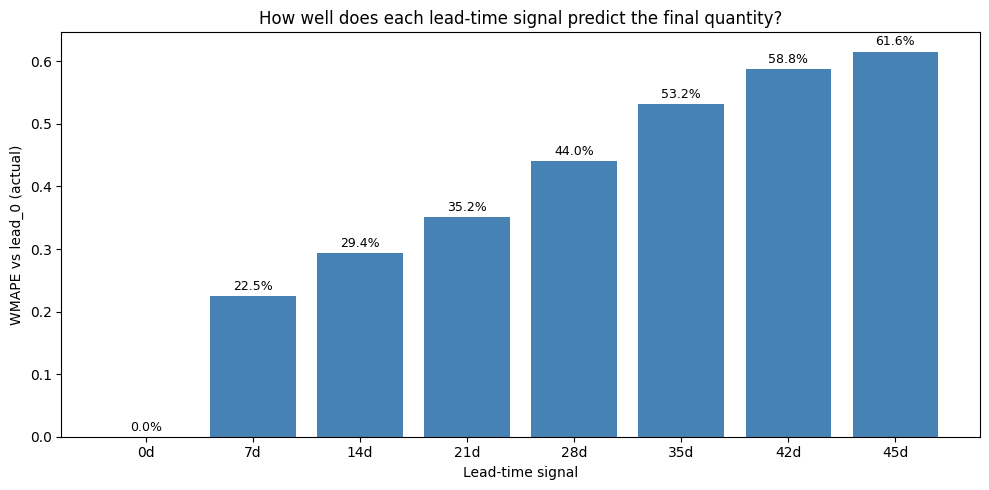

,WMAPE_vs_lead_0
signal,
lead_0,0.000000
lead_7,0.225245
lead_14,0.294139
lead_21,0.351711
lead_28,0.439940
lead_35,0.531501
lead_42,0.587649
lead_45,0.615524


In [372]:
# Pivot aux from long to wide: one column per lead signal
aux_wide = aux.pivot_table(
    index=["date", "InternalPartNumber", "ABCCode"],
    columns="identifier",
    values="value",
    aggfunc="sum",
).reset_index()

aux_wide = aux_wide.sort_values("date")
aux_wide = aux_wide.loc[aux_wide["date"]>= "2024-01-01"]
aux_wide = aux_wide.loc[aux_wide["date"]< "2026-01-01"]

# Reorder lead columns numerically
lead_cols = sorted(
    [c for c in aux_wide.columns if c.startswith("lead_")],
    key=lambda c: int(c.split("_")[1]),
)

# WMAPE of each lead_k signal vs lead_0 (the "actual" / latest-snapshot quantity)
actual = aux_wide["lead_0"]

wmape_results = {}
for col in lead_cols:
    # if col == "lead_0":
    #     continue
    predicted = aux_wide[col]
    mask = actual.abs() > 0  # only where there's a nonzero actual
    wmape_val = (actual[mask] - predicted[mask]).abs().sum() / actual[mask].abs().sum()
    wmape_results[col] = wmape_val

wmape_df = pd.DataFrame.from_dict(wmape_results, orient="index", columns=["WMAPE_vs_lead_0"])
wmape_df.index.name = "signal"
wmape_df = wmape_df.sort_index(key=lambda x: x.map(lambda s: int(s.split("_")[1])))

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
days = [int(s.split("_")[1]) for s in wmape_df.index]
ax.bar(range(len(days)), wmape_df["WMAPE_vs_lead_0"], color="steelblue")
ax.set_xticks(range(len(days)))
ax.set_xticklabels([f"{d}d" for d in days])
for i, v in enumerate(wmape_df["WMAPE_vs_lead_0"]):
    ax.text(i, v + 0.005, f"{v:.1%}", ha="center", va="bottom", fontsize=9)
ax.set_xlabel("Lead-time signal")
ax.set_ylabel("WMAPE vs lead_0 (actual)")
ax.set_title("How well does each lead-time signal predict the final quantity?")
plt.tight_layout()
plt.show()

wmape_df

/var/folders/fj/lf41s2h17nbgr6r8vnlcyb4c0000gr/T/ipykernel_98625/1780658628.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=[f"{int(s.split('_')[1])}d" for s in signals_sorted],


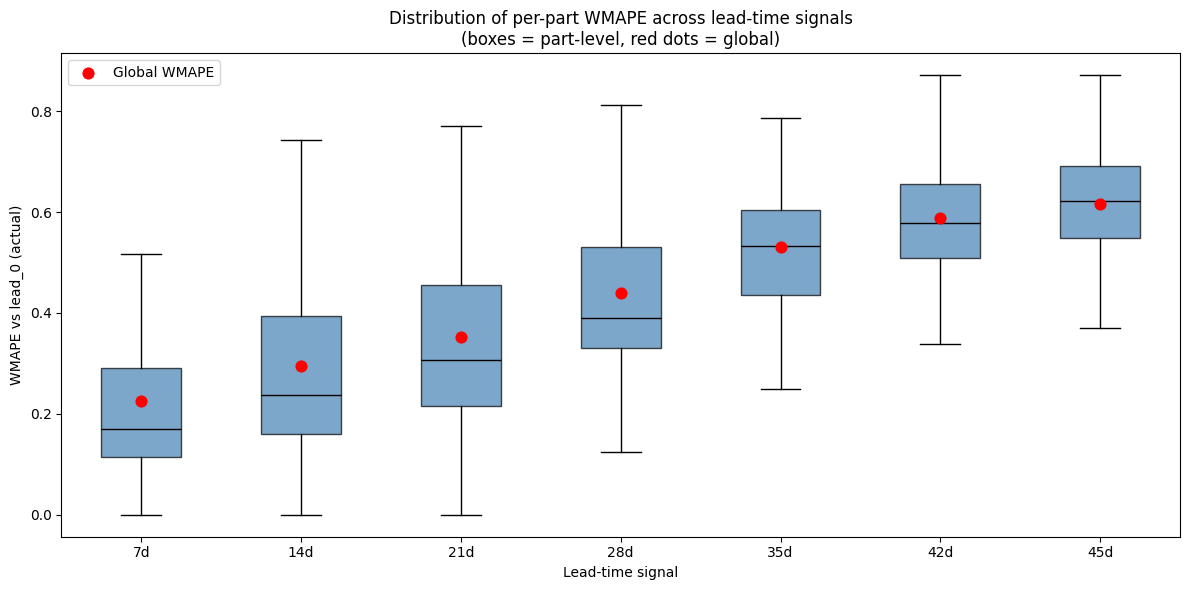

In [373]:
# Per-part WMAPE for each lead signal vs lead_0
actual_col = "lead_0"
rows = []
for part, grp in aux_wide.groupby("InternalPartNumber"):
    act = grp[actual_col]
    denom = act.abs().sum()
    if denom == 0:
        continue
    for col in lead_cols:
        if col == "lead_0":
            continue
        wmape_val = (act - grp[col]).abs().sum() / denom
        rows.append({"InternalPartNumber": part, "signal": col, "wmape": wmape_val})

wmape_per_part = pd.DataFrame(rows)
wmape_per_part["lead_days"] = wmape_per_part["signal"].str.split("_").str[1].astype(int)

# Box plot — distribution of per-part WMAPE across lead signals
fig, ax = plt.subplots(figsize=(12, 6))
signals_sorted = sorted(wmape_per_part["signal"].unique(), key=lambda s: int(s.split("_")[1]))
data_to_plot = [wmape_per_part.loc[wmape_per_part["signal"] == s, "wmape"].values for s in signals_sorted]
bp = ax.boxplot(data_to_plot, labels=[f"{int(s.split('_')[1])}d" for s in signals_sorted],
                patch_artist=True, showfliers=False, medianprops=dict(color="black"))
for patch in bp["boxes"]:
    patch.set_facecolor("steelblue")
    patch.set_alpha(0.7)

# Overlay the global WMAPE as red dots
global_vals = [wmape_df.loc[s, "WMAPE_vs_lead_0"] for s in signals_sorted]
ax.scatter(range(1, len(signals_sorted) + 1), global_vals, color="red", zorder=5, s=60, label="Global WMAPE")

ax.set_xlabel("Lead-time signal")
ax.set_ylabel("WMAPE vs lead_0 (actual)")
ax.set_title("Distribution of per-part WMAPE across lead-time signals\n(boxes = part-level, red dots = global)")
ax.legend()
plt.tight_layout()
plt.show()

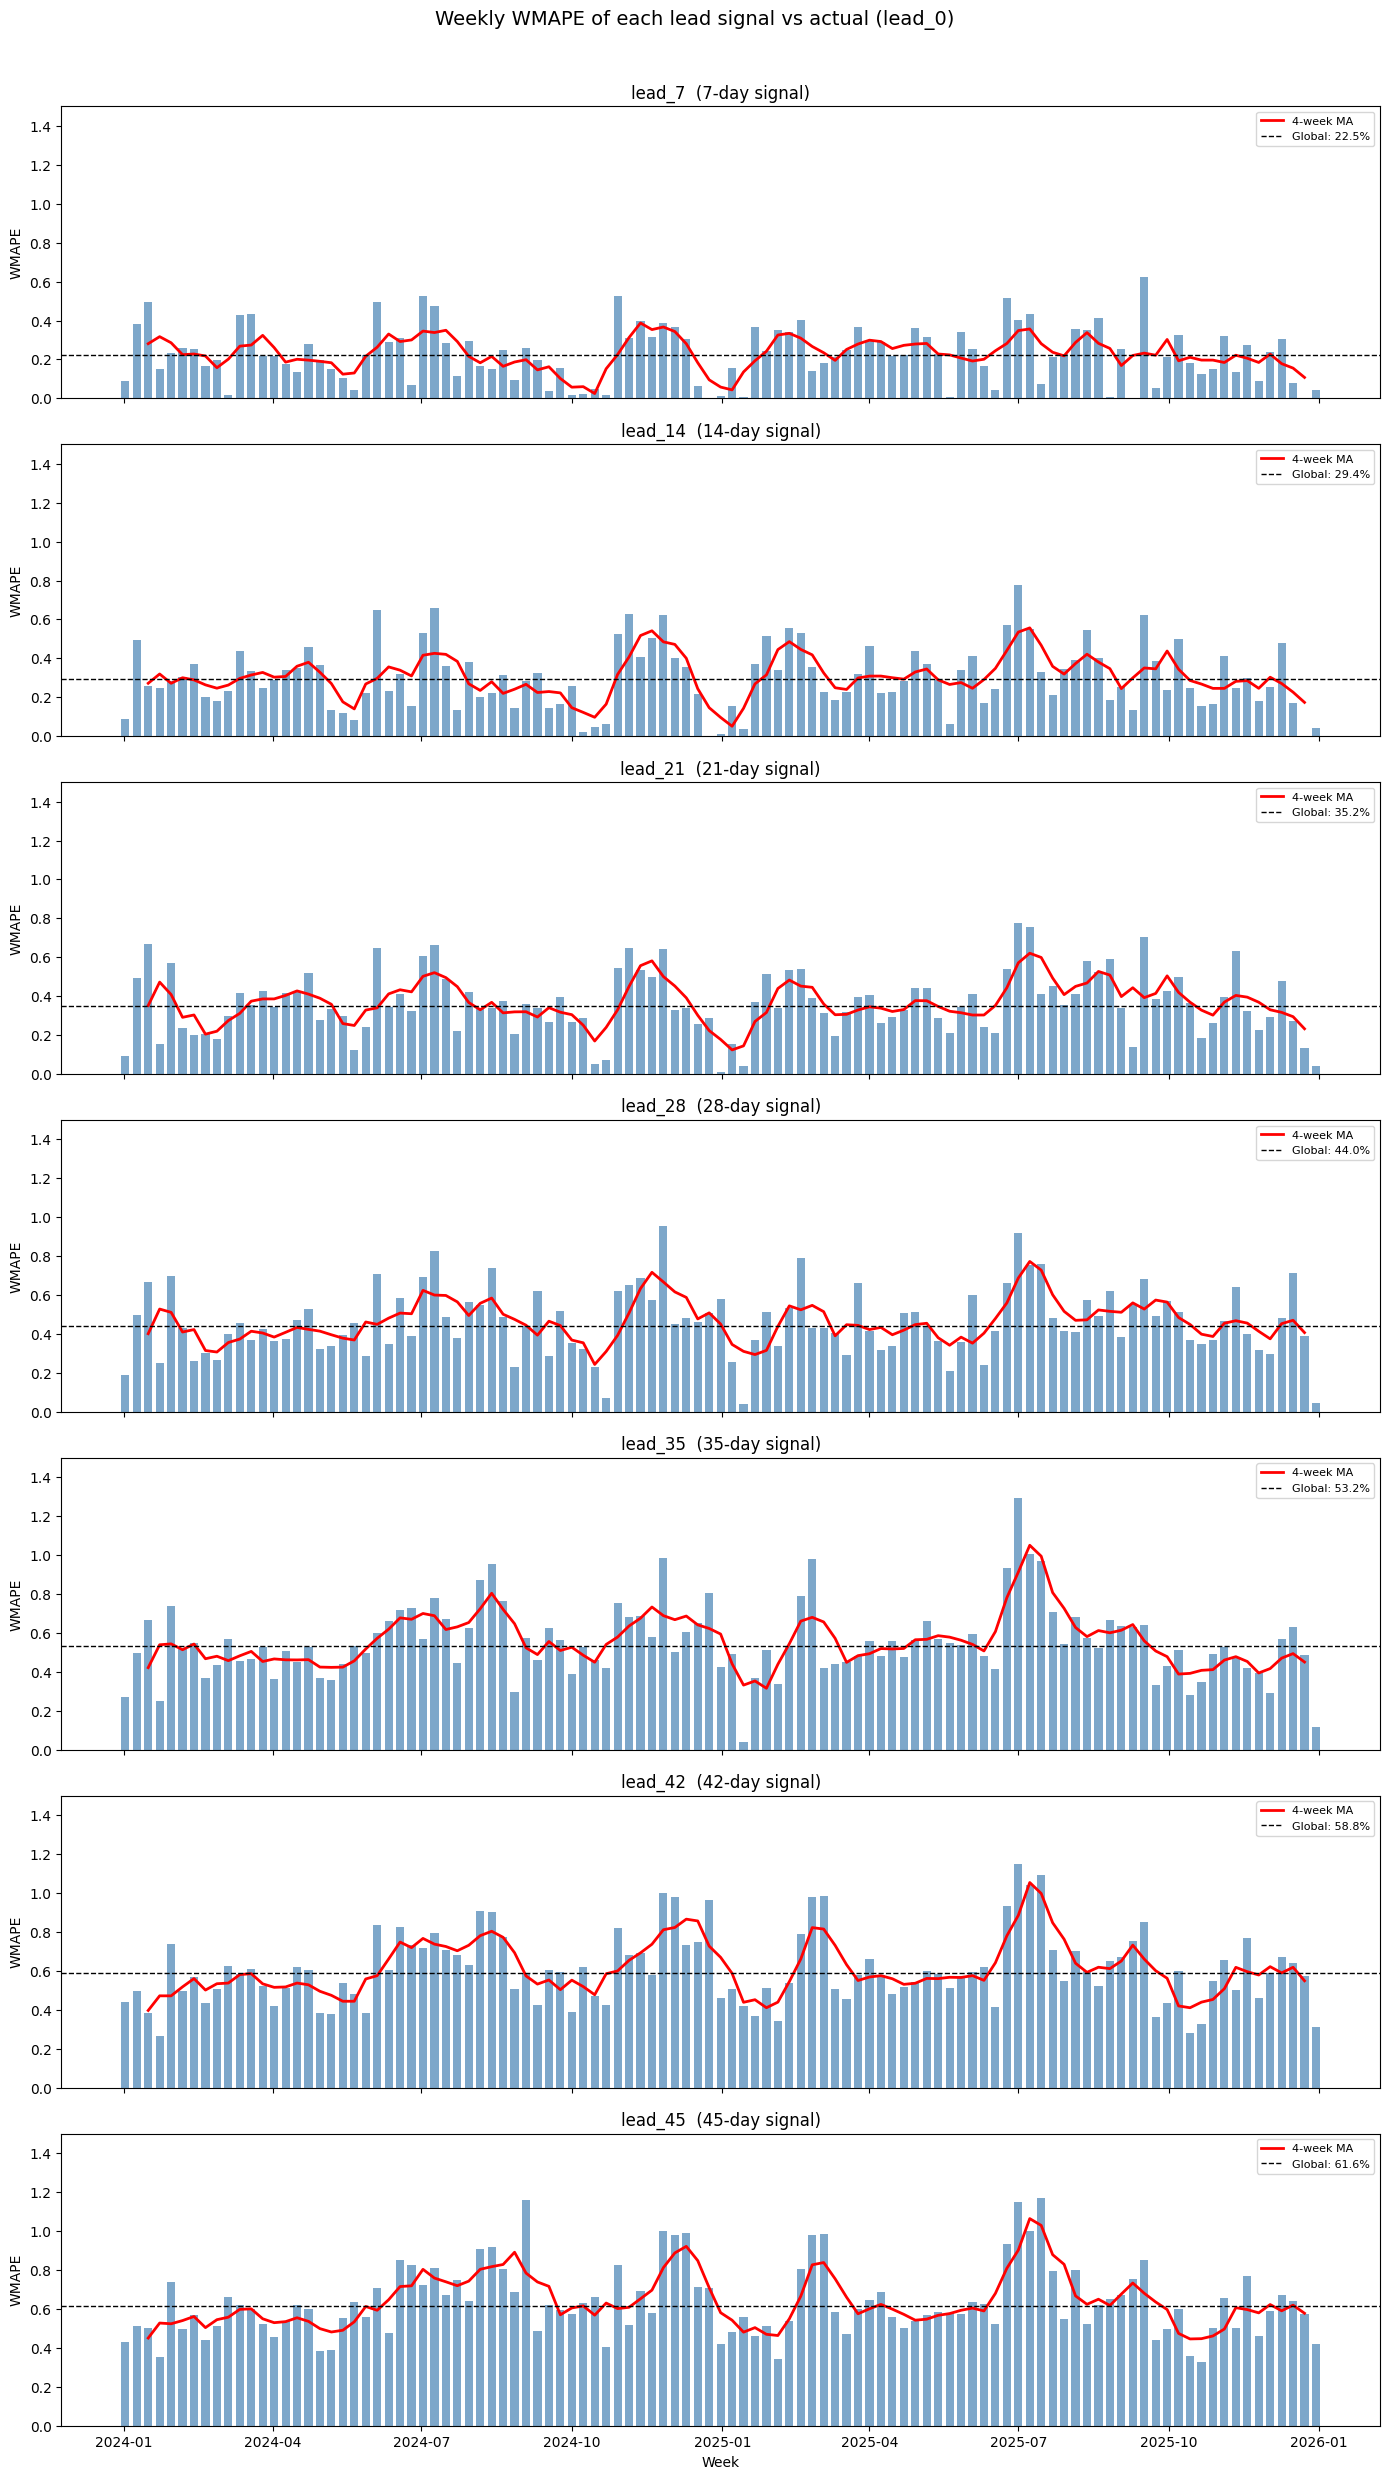

In [374]:
# Per-date WMAPE for each lead signal vs lead_0, one subplot per lead
signals_sorted = sorted(
    [c for c in lead_cols if c != "lead_0"],
    key=lambda s: int(s.split("_")[1]),
)

n = len(signals_sorted)
fig, axes = plt.subplots(n, 1, figsize=(14, 3.5 * n), sharex=True, sharey=True)

for i, sig in enumerate(signals_sorted):
    ax = axes[i]
    days_label = int(sig.split("_")[1])

    # Compute WMAPE per date
    per_date = []
    for dt, grp in aux_wide.groupby("date"):
        act = grp["lead_0"]
        denom = act.abs().sum()
        if denom == 0:
            continue
        w = (act - grp[sig]).abs().sum() / denom
        per_date.append({"date": dt, "wmape": w})

    pdf = pd.DataFrame(per_date).sort_values("date")
    pdf["date"] = pd.to_datetime(pdf["date"])

    ax.bar(pdf["date"], pdf["wmape"], width=5, color="steelblue", alpha=0.7)
    # Rolling average
    if len(pdf) >= 4:
        ax.plot(pdf["date"], pdf["wmape"].rolling(4, center=True).mean(),
                color="red", linewidth=2, label="4-week MA")
    ax.axhline(wmape_df.loc[sig, "WMAPE_vs_lead_0"], color="black",
               linestyle="--", linewidth=1, label=f"Global: {wmape_df.loc[sig, 'WMAPE_vs_lead_0']:.1%}")
    ax.set_ylabel("WMAPE")
    ax.set_title(f"lead_{days_label}  ({days_label}-day signal)")
    ax.legend(loc="upper right", fontsize=8)
    ax.set_ylim(0, 1.5)

axes[-1].set_xlabel("Week")
fig.suptitle("Weekly WMAPE of each lead signal vs actual (lead_0)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

identifier,date,InternalPartNumber,ABCCode,lead_0,lead_14,lead_21,lead_28,lead_35,lead_42,lead_45,lead_7
0,2023-05-30,92324A,A,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
200,2023-05-30,94732D,A,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
272,2023-05-30,99098AW,A,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
271,2023-05-30,99097M,Unknown,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
270,2023-05-30,99097M,C,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
54127,2025-12-30,94052BR,Unknown,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
54126,2025-12-30,94052BR,C,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
54136,2025-12-30,94052DF,A,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
54198,2025-12-30,94732B,C,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
